In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [9]:
def get_cifar10_loaders(batch_size=128, num_workers=2):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)

    trainloader = DataLoader(trainset, batch_size=batch_size,
                             shuffle=True, num_workers=num_workers)
    testloader = DataLoader(testset, batch_size=batch_size,
                            shuffle=False, num_workers=num_workers)
    return trainloader, testloader

In [10]:
# Architecture
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_branches=3):
        super(IntermediateBlock, self).__init__()
        self.num_branches = num_branches

        # independent conv branches.
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in range(num_branches)
        ])

        # weight vector a from a single FC layer
        self.weight_fc = nn.Linear(in_channels, num_branches)

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        a = F.softmax(self.weight_fc(m), dim=1)
        out = 0
        branch_outputs = [branch(x) for branch in self.branches]
        for i in range(self.num_branches):
            ai = a[:, i].view(-1, 1, 1, 1)
            out += ai * branch_outputs[i]
        return out


class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )


        self.b1 = IntermediateBlock(64, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.b2 = IntermediateBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.b3 = IntermediateBlock(128, 128)

        # Output block
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.b1(x))
        x = self.pool2(self.b2(x))
        x = self.b3(x)
        m = x.mean(dim=(2, 3))
        return self.classifier(m)


# Kaiming (He) initialization for Conv2d and Linear layers.
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

In [11]:
def train_and_test(model, dataloader, optimizer, loss_fn, device,
                   training, batch_losses=None):
    model.train() if training else model.eval()
    running_loss = correct = total = 0

    with torch.set_grad_enabled(training):
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            if training:
                optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            if training:
                loss.backward()
                optimizer.step()
                if batch_losses is not None:
                    batch_losses.append(loss.item())

            running_loss += loss.item() * inputs.size(0)
            correct += outputs.max(1)[1].eq(targets).sum().item()
            total += targets.size(0)

    return running_loss / total, correct / total

In [12]:
def train_model(epochs=100, batch_size=128, lr=0.1, weight_decay=5e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    trainloader, testloader = get_cifar10_loaders(batch_size=batch_size)

    model = CustomCNN().to(device)
    model.apply(init_weights)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                          weight_decay=weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'test_loss': [],
               'train_acc': [],  'test_acc':  []}
    batch_losses = []
    best_test_acc = 0.0


    for epoch in range(epochs):
        train_loss, train_acc = train_and_test(
            model, trainloader, optimizer, loss_fn, device,
            training=True, batch_losses=batch_losses)
        test_loss, test_acc = train_and_test(
            model, testloader, optimizer, loss_fn, device, training=False)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc * 100)
        history['test_acc'].append(test_acc * 100)

        if test_acc * 100 > best_test_acc:
            best_test_acc = test_acc * 100


        print(f"Epoch {epoch+1:3d}/{epochs}  "
              f"lr={optimizer.param_groups[0]['lr']:.4f}  "
              f"train_loss={train_loss:.4f} test_loss={test_loss:.4f}  "
              f"train_acc={train_acc*100:.2f}% test_acc={test_acc*100:.2f}%  "
              f"(best={best_test_acc:.2f}%)")



    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Loss for each training batch
    axes[0].plot(batch_losses)
    axes[0].set_title("Training loss per batch")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")

    # Training and testing accuracy per epoch
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['test_acc'],  label='Test')
    axes[1].set_title("Accuracy per epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()


    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()

    return model, history, batch_losses, best_test_acc

Using device: cuda
Epoch   1/50  lr=0.0999  train_loss=1.6913 test_loss=1.4189  train_acc=36.24% test_acc=46.93%  (best=46.93%)
Epoch   2/50  lr=0.0996  train_loss=1.3124 test_loss=2.8870  train_acc=52.28% test_acc=32.33%  (best=46.93%)
Epoch   3/50  lr=0.0991  train_loss=1.1310 test_loss=1.1090  train_acc=60.09% test_acc=59.25%  (best=59.25%)
Epoch   4/50  lr=0.0984  train_loss=1.0170 test_loss=1.1091  train_acc=64.57% test_acc=61.41%  (best=61.41%)
Epoch   5/50  lr=0.0976  train_loss=0.9356 test_loss=1.0469  train_acc=67.75% test_acc=62.56%  (best=62.56%)
Epoch   6/50  lr=0.0965  train_loss=0.8787 test_loss=0.9075  train_acc=69.93% test_acc=68.70%  (best=68.70%)
Epoch   7/50  lr=0.0952  train_loss=0.8290 test_loss=0.9942  train_acc=71.96% test_acc=65.59%  (best=68.70%)
Epoch   8/50  lr=0.0938  train_loss=0.7823 test_loss=0.8262  train_acc=73.63% test_acc=72.33%  (best=72.33%)
Epoch   9/50  lr=0.0922  train_loss=0.7525 test_loss=0.8856  train_acc=74.94% test_acc=70.75%  (best=72.33%)


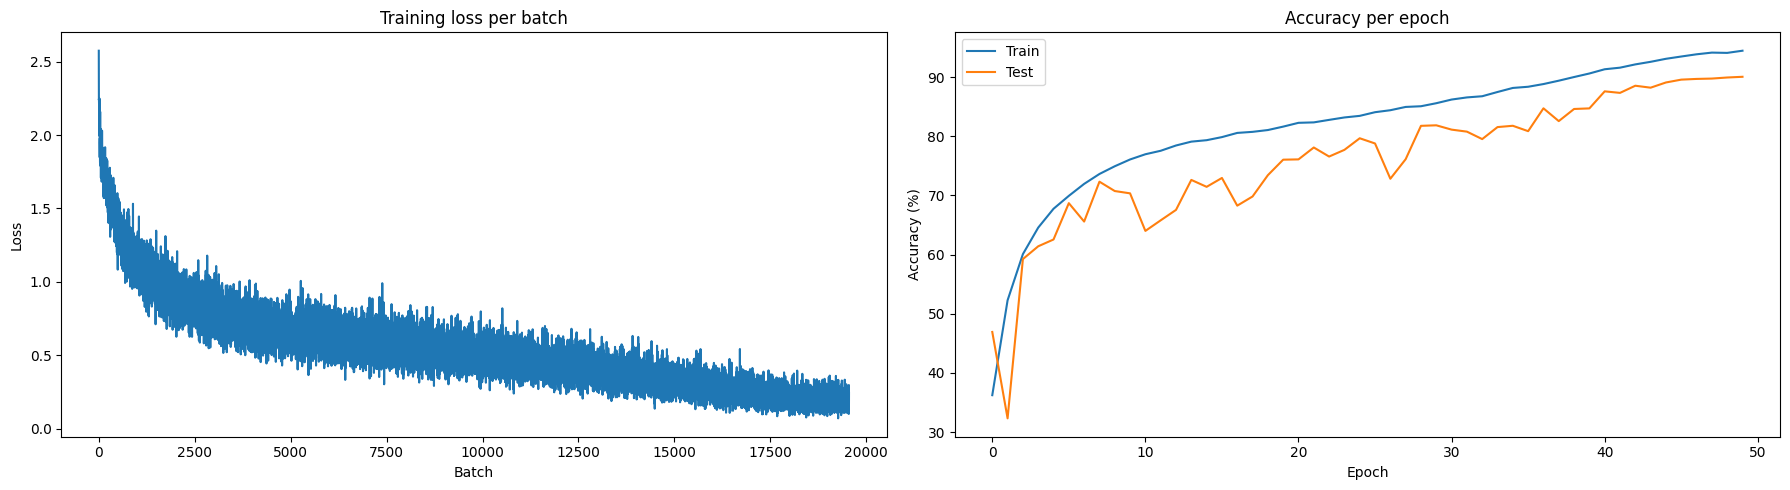

In [13]:

model, history, batch_losses, best_test_acc = train_model(epochs=50)